# Exercise 1

**Due date:** Long overdue 👀

**Learning goals:** F-matrix estimation

In [1]:
import cv2
import numpy as np
from scipy.linalg import svd
from skimage.color import rgb2gray

from middlebury_data_loader import MiddleburyStereoDataset
from p1_utils import extract_kps_and_calc_transform, apply_transform
from utils import display_epipolar_lines

## Task 1: Take pictures

I will simply use the Middlebury Stereo Dataset for now

In [2]:
ds = MiddleburyStereoDataset()
ds.keys()

dict_keys(['Pipes', 'Backpack', 'Classroom1', 'Shopvac', 'Playroom', 'Bicycle1', 'Sword2', 'Adirondack', 'Playtable', 'Motorcycle', 'Umbrella', 'Flowers', 'Jadeplant', 'Storage', 'Recycle', 'Shelves', 'Sticks', 'Mask', 'Piano', 'Cable', 'Sword1', 'Vintage', 'Couch'])

In [3]:
scene = ds['Adirondack']['perfect']
image1, image2 = rgb2gray(scene.left), rgb2gray(scene.right)

## Task 2: Extract and Plot KP and Matches

start kp extraction.
extraction successful. image1: 4535 kps | image2: 4338 kps.
start matching.
matching successful. matched 2901 kps.
start outlier removal.
outlier removal successful. dropped: 13 kps | remaining: 2888 kps.
calculate transform.
transform calculated.
apply transform.
transform applied.
display matches and transform...


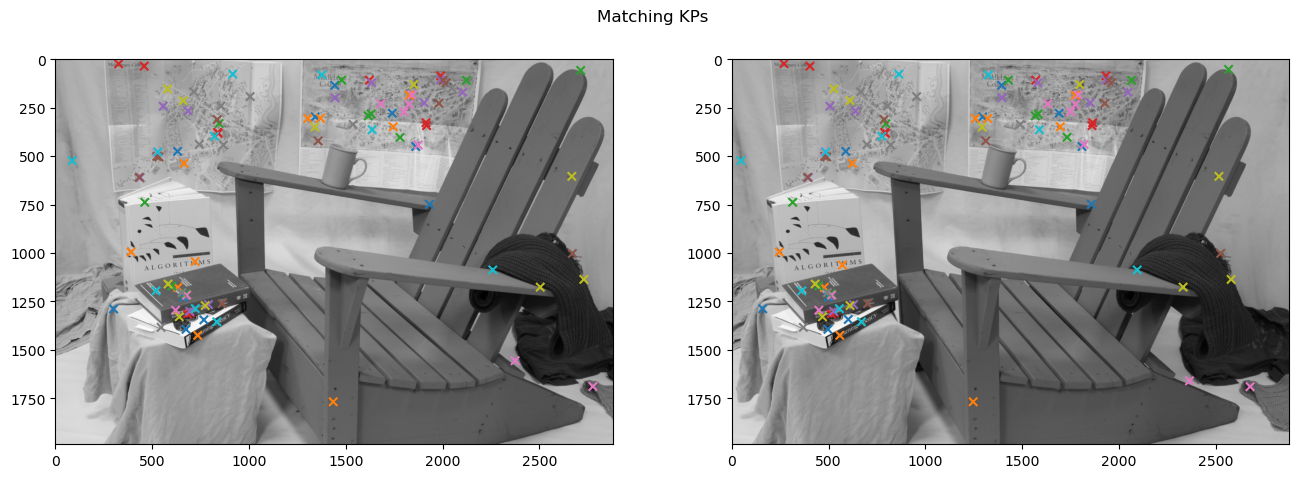

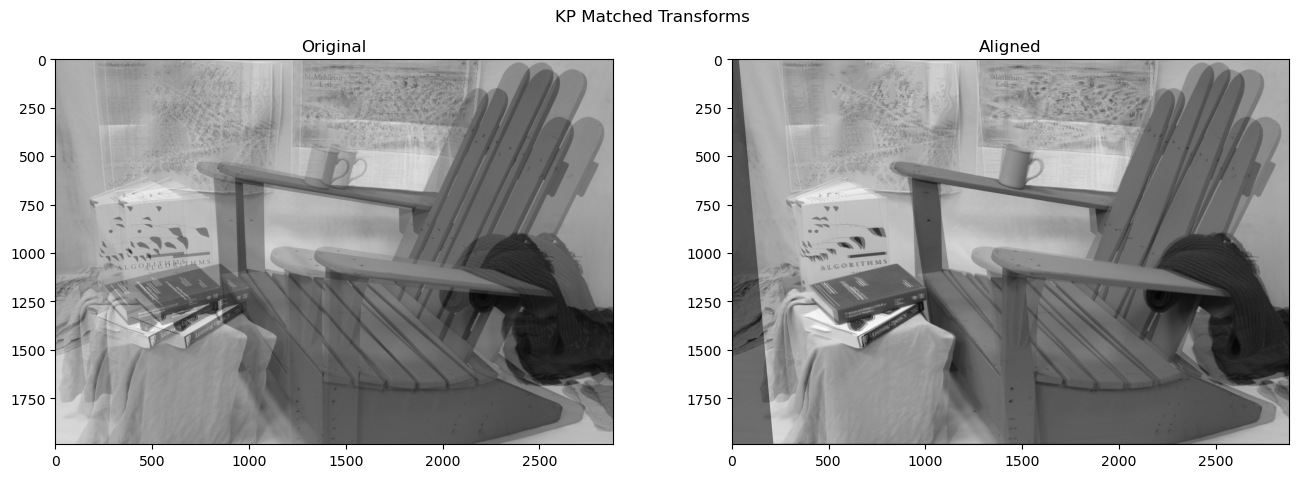

In [4]:
extractions = extract_kps_and_calc_transform(image1, image2, display=True)

## Task 3: Estimate the fundamental matrix

In [5]:
def create_A(matched_points: np.ndarray):
    ul = matched_points[:, 0, 0]
    vl = matched_points[:, 0, 1]
    ur = matched_points[:, 1, 0]
    vr = matched_points[:, 1, 1]

    ones = np.ones_like(ul)
    return np.stack([
        ul * ur, ul * vr, ul,
        vl * ur, vl * vr, vl,
        ur, vr, ones
    ], axis=1)

In [6]:
def solve_F(A):
    # Solve Af = 0 by SVD
    U, S, Vt = svd(A)
    f = Vt[-1]
    F = f.reshape(3, 3)

    # Enforce rank-2: zero out smallest singular value
    U, S, Vt = svd(F)
    S[-1] = 0
    return U @ np.diag(S) @ Vt

In [7]:
def eight_point_algorithm(pts):
    pl = pts[:, 0]
    pr = pts[:, 1]

    def normalize(pts):
        mean = pts.mean(axis=0)
        shifted = pts - mean
        mean_dist = np.mean(np.sqrt((shifted ** 2).sum(axis=1)))
        scale = np.sqrt(2) / mean_dist
        T = np.array([
            [scale, 0, -scale * mean[0]],
            [0, scale, -scale * mean[1]],
            [0, 0, 1]
        ])
        pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])
        pts_norm_h = (T @ pts_h.T).T
        return pts_norm_h[:, :2], T

    pl_norm, T_left = normalize(pl)
    pr_norm, T_right = normalize(pr)

    matched_norm = np.stack([pl_norm, pr_norm], axis=1)
    A_norm = create_A(matched_norm)
    F_norm = solve_F(A_norm)

    # Denormalize: F = T_right^T * F_norm * T_left
    return T_right.T @ F_norm @ T_left

In [8]:
F = eight_point_algorithm(extractions['keypoints'])

In [9]:
_, H1, H2 = cv2.stereoRectifyUncalibrated(
    extractions['keypoints'][:, 0],
    extractions['keypoints'][:, 1],
    F,
    (image2.shape[1], image2.shape[0]),
)

In [10]:
H1

array([[-1.32376531e-03,  1.84330613e-04,  1.71176368e-01],
       [-6.22297967e-05, -1.26060732e-03,  1.19834456e-01],
       [-8.72227453e-08, -4.80258295e-09, -1.08613029e-03]])

In [11]:
image1_rect = apply_transform(image1, np.linalg.inv(H1))
image2_rect = apply_transform(image2, np.linalg.inv(H2))

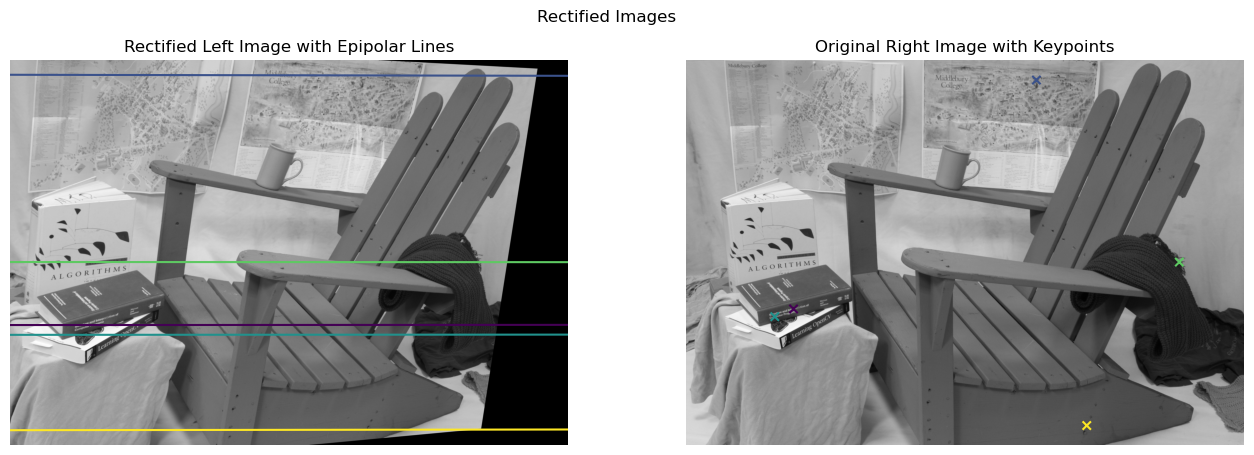

In [12]:
display_epipolar_lines(image1_rect, image2, F, H1, extractions['keypoints'])